# Imports

In [1]:
%load_ext autoreload
%autoreload 2
import gc
import os
import sys
import random
import wandb
sys.path.append('../utils')
sys.path.append('../data_utils')
sys.path.append('../models')
import numpy as np
import matplotlib.pyplot as plt
from ABC_dataset import get_item, ABCdataset, get_vdb_data_loader
import mesh_tools as mt
import fvdb_utils as fu
import model as fvdbModel
import unet as fvdbUnet
import igl
from meshplot import plot
import fvdb
import fvdb.nn as fvnn
import torch
import torch.nn as nn
from tqdm import tqdm
from skimage import measure
import trimesh

# Args

In [2]:
pos_enc_dim=10
device = 'cuda' if torch.cuda.is_available() else 'cpu'
sdf_dir = '/data/workspaces/spanwar/dataset/ssu_data/ssu_processed_data/sdf_data_unit_circle_norm'
sdf_nmc_dir = '/data/workspaces/spanwar/dataset/nmc_data/groundtruth/gt_NMC'
ponq_data_dir = '/data/workspaces/spanwar/dataset/ponq_dataset/gt_Quadrics'

# Load Dataset

In [3]:
train_set_names = os.listdir(ponq_data_dir)

In [4]:
random.shuffle(train_set_names)
train_size = int(0.6 * len(train_set_names))
test_size = int(0.2 * len(train_set_names))
val_size = len(train_set_names) - train_size - test_size
train_names = train_set_names[:train_size]
val_names = train_set_names[train_size:train_size + val_size]
test_names = train_set_names[train_size + val_size:]

train_dataset = ABCdataset(ponq_data_dir, train_names)
val_dataset = ABCdataset(ponq_data_dir, val_names)
test_dataset = ABCdataset(ponq_data_dir, test_names, mode='test')

print(f'Number of samples in the dataset: {len(train_set_names)}')
print(f'Number of samples in the train set: {len(train_dataset)}')
print(f'Number of samples in the test set: {len(test_dataset)}')
print(f'Number of samples in the validation set: {len(val_dataset)}')

100%|██████████| 1433/1433 [00:01<00:00, 822.09it/s]


Number of samples in the dataset: 7168
Number of samples in the train set: 4300
Number of samples in the test set: 1433
Number of samples in the validation set: 1435


In [5]:
# %reload_ext autoreload
train_data_loader = get_vdb_data_loader(train_dataset, batch_size=1, shuffle=True, num_workers=0)
val_data_loader = get_vdb_data_loader(val_dataset, batch_size=1, shuffle=False, num_workers=0)
test_data_loader = get_vdb_data_loader(test_dataset, batch_size=1, shuffle=False, num_workers=0, mode='test')

# Load Model

In [6]:
def positional_encoding(small_vdb, dim):
    '''helps the learning'''
    feat = small_vdb.jdata
    half_dim = dim // 2
    emb = torch.arange(
        start=0, end=half_dim, dtype=torch.float32, device=feat.device)
    emb = 2**emb * torch.pi
    emb = feat.float() * emb[None, :]
    new_feat = torch.cat([feat, emb.sin(), emb.cos()], dim=-1)
    return fvnn.VDBTensor(small_vdb.grid, small_vdb.grid.jagged_like(new_feat))

In [7]:
model = fvdbUnet.FVDBUNetBaseUpsampler(in_channels=pos_enc_dim+1, out_channels=1)
model = model.to(device)

In [8]:
# model summary and parameters
def print_model_summary(model):
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters: {total_params}")
    print(f"Trainable parameters: {trainable_params}")
print_model_summary(model)
# show model architecture
print(model)

Total parameters: 21988577
Trainable parameters: 21988577
FVDBUNetBaseUpsampler(
  (conv0p1s1): SparseConv3d(11, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseCon

# Train the model

In [9]:
model_name = 'Unet' 
wandb_model_name = 'SSU_PONQ_DATA_UPSAMPLER_Unet'

In [10]:
# wandb.init(project="SSU", entity="sp_kumar", name=f"{wandb_model_name}", config={
#     "Discpription": "Implementing simple CNN model that upsacale using one transposed layer using PONQ Dataset",
#     "batch_size": 1,
#     "learning_rate": 1e-3,
#     "epochs": 10,
#     "positional_encoding_dim": 10,
#     "model": f"{model_name}",
#     "dataset": "PONQ Dataset",
#     "dataset_size": len(train_set_names),
#     "dataset_split": {
#         "train": len(train_dataset),
#         "val": len(val_dataset),
#         "test": len(test_dataset)
#     },
#     "model_parameters": sum(p.numel() for p in model.parameters() if p.requires_grad),
#     "loss_function": "MSE loss",
#     "optimizer": "Adam",
#     "device": device
# })

In [11]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
criterion = nn.MSELoss()

In [12]:
def train(model, train_data_loader, val_data_loader, optimizer, criterion, epochs, device):
    history = []
    saliency_labels = ['sdf'] + [f'pos_enc_{i}' for i in range(pos_enc_dim)]
    saliency_feature = []
    min_val_loss = float('inf')
    
    for epoch in range(epochs):
        epoch_loss = 0
        Loss = []
        saliency_feature_epoch = []
        
        model.train()
        for small_vdb, large_vdb in tqdm(train_data_loader, desc=f'Epoch {epoch+1}/{epochs}'):
            small_vdb = positional_encoding(small_vdb, pos_enc_dim)
            small_vdb.jdata.requires_grad_()
            small_vdb = small_vdb.to(device)
            large_vdb = large_vdb.to(device)

            optimizer.zero_grad()
            out = model(small_vdb, large_vdb.grid)
            loss = criterion(out.jdata, large_vdb.data.jdata)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()

            # save saliency 
            saliency_feature_epoch.append(small_vdb.jdata.grad.abs().mean(dim=0).cpu().numpy())

        # average saliency
        saliency_feature.append(np.stack(saliency_feature_epoch).mean(axis=0))

        # loss
        avg_loss = epoch_loss / len(train_data_loader)
        Loss.append(avg_loss)
        print(f'Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}')

        # Validation
        with torch.no_grad():
            
            model.eval()
            val_loss = 0
            
            for small_vdb, large_vdb in tqdm(val_data_loader, desc='Validation'):
                small_vdb = positional_encoding(small_vdb, pos_enc_dim)
                small_vdb = small_vdb.to(device)
                large_vdb = large_vdb.to(device)
                
                out = model(small_vdb, large_vdb.grid)
                loss = criterion(out.jdata, large_vdb.data.jdata)
                
                val_loss += loss.item()
            
            avg_val_loss = val_loss / len(val_data_loader)
            print(f'Validation Loss: {avg_val_loss:.4f}')

        # save best model
        if avg_val_loss < min_val_loss:
            min_val_loss = avg_val_loss
            torch.save(model, f'../save_models/{wandb_model_name}.pth')
            print(f'Saved best model at epoch {epoch+1} with validation loss: {min_val_loss:.4f}')
        
        Loss.append(avg_val_loss)
        # wandb.log({
        # "train_loss": avg_loss,
        # "val_loss": avg_val_loss,
        # "epoch": epoch})

        history.append(Loss)

    # save saliency feature
    epochs = np.arange(1, len(saliency_feature) + 1)
    saliency_feature = np.array(saliency_feature)
    # percentage each row
    def get_percentages(arr):
        arr = np.asarray(arr)
        if arr.ndim == 1:
            return arr / np.sum(arr)
        else:
            return arr / np.sum(arr, axis=1, keepdims=True)
    saliency_percent = get_percentages(saliency_feature)
    saliency_percent = np.array(saliency_percent).T
    
    plt.figure(figsize=(10, 6))
    for i, label in enumerate(saliency_labels):
        plt.plot(epochs, saliency_percent[i], label=label)
    plt.xlabel("Epoch")
    plt.ylabel("Feature Importance in %")
    plt.title("Saliency Feature Importance Over Epochs of Last Train Example")
    plt.legend()
    plt.tight_layout()
    # plt.plot()

    # # Log the plot to wandb
    # wandb.log({"Saliency feature importance over epochs of last train example": wandb.Image(plt)})
    plt.close()

    return history

In [13]:
gc.collect()
torch.cuda.empty_cache()

In [14]:
history = train(model, 
                train_data_loader, 
                val_data_loader, 
                optimizer, 
                criterion, 
                epochs=10, 
                device=device)

Epoch 1/10: 100%|██████████| 4300/4300 [07:32<00:00,  9.51it/s]


Epoch 1/10, Loss: 0.0478


Validation: 100%|██████████| 1435/1435 [01:34<00:00, 15.18it/s]


Validation Loss: 0.0112
Saved best model at epoch 1 with validation loss: 0.0112


Epoch 2/10: 100%|██████████| 4300/4300 [07:29<00:00,  9.57it/s]


...

Validation Loss: 0.0054


Epoch 10/10: 100%|██████████| 4300/4300 [07:23<00:00,  9.69it/s]


Epoch 10/10, Loss: 0.0061


Validation: 100%|██████████| 1435/1435 [01:34<00:00, 15.16it/s]


Validation Loss: 0.0053


# Plot

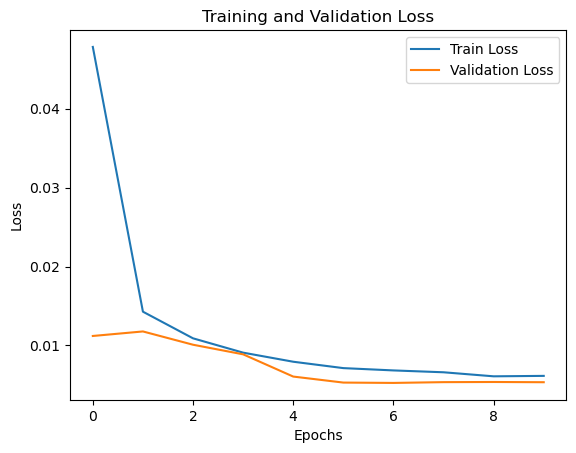

In [15]:
plt.plot(history)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend(['Train Loss', 'Validation Loss'])
plt.show()

In [16]:
# load save model
model = torch.load(f'../save_models/{wandb_model_name}.pth')
model.eval()

/tmp/ipykernel_830917/1774082674.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load(f'../save_models/{wandb_model_name}.pth')


FVDBUNetBaseUpsampler(
  (conv0p1s1): SparseConv3d(11, 32, kernel_size=(5, 5, 5), bias=False)
  (bn0): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv1p1s2): SparseConv3d(32, 32, kernel_size=(2, 2, 2), stride=(2, 2, 2), bias=False)
  (bn1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (block1): Sequential(
    (0): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm1): BatchNorm(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): SparseConv3d(32, 32, kernel_size=(3, 3, 3))
      (norm2): BatchNor

In [17]:
# idx = random.randint(0, len(test_dataset)-1)
idx=0
small_sdf, large_sdf, mask, input, actual = test_dataset[idx]
input = positional_encoding(input, pos_enc_dim).to(device)
actual = actual.to(device)

# large grid from small VDBTensor
small_vdb, large_grid = fu.sdf_to_vdb(small_sdf, 
                                      None, 
                                      mask = mask, 
                                      size=33, mode='test')

pred = model(input, large_grid)

In [18]:
def upload_plot_mesh_to_wandb(v, f, title):
    """Upload a mesh to wandb"""
    fig = plt.figure(figsize=(6, 6))
    ax = fig.add_subplot(111, projection='3d')
    # Plot the mesh using trisurf
    ax.plot_trisurf(v[:, 0], v[:, 1], v[:, 2], triangles=f, cmap='viridis', edgecolor='none', alpha=0.8)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    
    # Log to wandb
    wandb.log({f'mesh_image: {title}': wandb.Image(fig)})
    plt.close(fig)

In [19]:
v, f = fu.vdb_marching_cubes(small_vdb)
# upload_plot_mesh_to_wandb(v, f, title='small SDF')
plot(v,f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [20]:
v, f = fu.vdb_marching_cubes(pred)
# upload_plot_mesh_to_wandb(v, f, title='predition')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(-0.001337…

In [21]:
v, f = fu.vdb_marching_cubes(actual)
# upload_plot_mesh_to_wandb(v, f, title='GT: large SDF')
plot(v, f)

Renderer(camera=PerspectiveCamera(children=(DirectionalLight(color='white', intensity=0.6, position=(0.0, 0.0,…

In [ ]:
wandb.finish()